# 02 — Customer Churn modular training pipeline

**Training dataset:** `archive/Customer-Churn-Records.csv`  
**External test:** `archive/Synthetic-Customer-Churn-Test.csv`  
**Target:** `Exited`

Notebook này chỉ điều phối và trình bày kết quả. Toàn bộ feature engineering, preprocessing, model, tuning, evaluation và plotting nằm trong package [`pipeline/`](pipeline/README.md).

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Step 0 — Config và imports

Config tập trung tại `pipeline/config.py`; thay split, threshold hoặc tuning budget tại một nơi.

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from pipeline.config import DEFAULT_CONFIG
from pipeline.data import load_and_split_data
from pipeline.evaluation import (
    build_validation_results,
    evaluate_external_test,
    select_tuned_model,
)
from pipeline.features import audit_risk_rules, build_feature_bundle
from pipeline.importance import calculate_source_importance
from pipeline.preprocessing import fit_preprocessors
from pipeline.reporting import build_conclusion_markdown, build_final_comparison
from pipeline.training import train_baseline_models
from pipeline.tuning import tune_models
from pipeline.visualization import (
    plot_external_evaluation,
    plot_feature_importance,
    plot_probability_separation,
    plot_threshold_selection,
    plot_validation_comparison,
    set_plot_style,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
set_plot_style()

config = DEFAULT_CONFIG
config

PipelineConfig(train_data_path=PosixPath('/Users/minh/churn-rate/archive/Customer-Churn-Records.csv'), external_test_path=PosixPath('/Users/minh/churn-rate/archive/Synthetic-Customer-Churn-Test.csv'), target='Exited', excluded_columns=('RowNumber', 'CustomerId', 'Surname', 'Complain'), validation_size=0.15, random_state=42, age_bins=5, operating_threshold=0.4, cv_tie_tolerance=0.002, tuning_iterations=18, cv_splits=5)

# Step 1 — Load, schema check và stratified split 85/15

Logic: `pipeline/data.py`. `CustomerId`, `RowNumber`, `Surname`, `Complain` và target bị loại trước khi split.

In [3]:
data = load_and_split_data(config)

display(data.split_summary.style.format({
    'Rows': '{:,}',
    'Churn rate': '{:.2%}',
}))
print(f'Raw model columns ({len(data.model_columns)}): {data.model_columns}')
print(f'Excluded from model: {[*config.excluded_columns, config.target]}')
print(f'Exact source/external feature-row overlap: {data.external_overlap}')

,Split,Source,Rows,Churn rate,Target use
0,Train,Customer-Churn-Records.csv,"8,500",20.38%,Model fitting and cross-validation
1,Validation,Customer-Churn-Records.csv,"1,500",20.40%,Operating comparison and model tie-break
2,External test,Synthetic-Customer-Churn-Test.csv,"1,000",20.40%,Final diagnostic evaluation only


Raw model columns (13): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Card Type', 'Point Earned']
Excluded from model: ['RowNumber', 'CustomerId', 'Surname', 'Complain', 'Exited']
Exact source/external feature-row overlap: 0


# Step 2 — Audit các risk rules trên train

Logic: `pipeline/features.py`. Audit chỉ đọc train để validation và external test không tác động đến cách xây rule.

In [4]:
risk_rule_audit = audit_risk_rules(data.X_train, data.y_train)
print(f'Train baseline churn rate: {data.y_train.mean():.2%}')
display(risk_rule_audit.style.format({
    'Support': '{:,}',
    'Exited': '{:,}',
    'Non-exited': '{:,}',
    'Exit rate': '{:.2%}',
    'Lift vs train baseline': '{:.2f}x',
}).background_gradient(
    subset=['Exit rate', 'Lift vs train baseline'],
    cmap='YlOrRd',
))

Train baseline churn rate: 20.38%


,Rule,Support,Exited,Non-exited,Exit rate,Lift vs train baseline
0,CreditScore <= 400 and inactive,12,12,0,100.00%,4.91x
1,Inactive member,"4,118","1,102","3,016",26.76%,1.31x
2,NumOfProducts >= 3,270,232,38,85.93%,4.22x
3,"CreditScore <= 425, Tenure < 5 and HasCrCard",19,8,11,42.11%,2.07x


# Step 3 — Train-fitted feature engineering

Logic: `pipeline/features.py`. `ChurnFeatureEngineer` là sklearn transformer nên được fit lại trong từng cross-validation fold.

In [5]:
features = build_feature_bundle(data, config)

print(f'Age edges learned from train: {features.engineer.age_edges_}')
print(
    'Older-customer threshold learned from train: '
    f'{features.engineer.older_age_threshold_:.1f}'
)
print(f'New engineered features ({len(features.engineered_feature_names)}):')
print(features.engineered_feature_names)
print(
    'Total engineered candidate columns: '
    f'{features.frames["engineered"]["train"].shape[1]}'
)
display(features.catalog)

Age edges learned from train: [-inf  31.  35.  39.  46.  inf]
Older-customer threshold learned from train: 44.0
New engineered features (23):
['ProductGroup', 'HasTwoProducts', 'HasThreePlusProducts', 'IsInactiveMember', 'VeryLowCreditScore', 'LowCreditScore425', 'ShortTenureUnder5', 'VeryLowCreditInactive', 'LowCreditShortTenureHasCard', 'InactiveWithOneProduct', 'InactiveWithThreePlusProducts', 'ZeroBalance', 'LogBalance', 'BalanceToSalary', 'BalancePerProduct', 'AgeGroup', 'IsOlderCustomer', 'InactiveWithBalance', 'InactiveWithMultipleProducts', 'CardButInactive', 'GeographyActivity', 'GeographyAgeGroup', 'PointsPerTenure']
Total engineered candidate columns: 36


,Feature,Type,Definition
0,ProductGroup,Categorical,1 product / 2 products / 3+ products
1,HasTwoProducts,Binary,NumOfProducts == 2
2,HasThreePlusProducts,Binary,NumOfProducts >= 3
3,IsInactiveMember,Binary,IsActiveMember == 0
4,VeryLowCreditScore,Binary,CreditScore <= 400
5,LowCreditScore425,Binary,CreditScore <= 425
6,ShortTenureUnder5,Binary,Tenure < 5
7,VeryLowCreditInactive,Binary interaction,CreditScore <= 400 and inactive
8,LowCreditShortTenureHasCard,Binary interaction,CreditScore <= 425 and Tenure < 5 and HasCrCar...
9,InactiveWithOneProduct,Binary interaction,Inactive and NumOfProducts == 1


# Step 4 — Preprocessing fit trên train

Logic: `pipeline/preprocessing.py`. Numeric được median-impute; categorical được most-frequent-impute và one-hot encode với unknown-category guard.

In [6]:
preprocessing = fit_preprocessors(features, config)
preprocessing.inventory

,Feature set,Input columns,Numeric columns,Categorical columns,Processed columns,Train matrix shape
0,raw,13,10,3,19,"(8500, 19)"
1,engineered,36,29,7,67,"(8500, 67)"


# Step 5 — Baseline và imbalance ablation

Model-specific code nằm tại `model_lightgbm.py`, `model_xgboost.py`, `model_random_forest.py`; orchestration nằm tại `pipeline/training.py`.

In [7]:
baseline_artifacts = train_baseline_models(data, preprocessing, config)

negative_count = int((data.y_train == 0).sum())
positive_count = int((data.y_train == 1).sum())
print(
    'Train class ratio n_negative / n_positive: '
    f'{negative_count / positive_count:.4f}'
)
for name, artifact in baseline_artifacts.items():
    print(
        f'{name}: algorithm={artifact.algorithm}, '
        f'best_iteration={artifact.best_iteration}, '
        f'time={artifact.training_seconds:.2f}s, '
        f'imbalance={artifact.imbalance_strategy}, '
        f'train_rows={artifact.training_rows:,}'
    )

Train class ratio n_negative / n_positive: 3.9076
Raw LGBM: algorithm=LightGBM, best_iteration=185, time=1.19s, imbalance=None, train_rows=8,500
Engineered LGBM: algorithm=LightGBM, best_iteration=215, time=1.54s, imbalance=None, train_rows=8,500
Engineered + weight: algorithm=LightGBM, best_iteration=136, time=1.16s, imbalance=scale_pos_weight, train_rows=8,500
Engineered + oversampling: algorithm=LightGBM, best_iteration=158, time=1.36s, imbalance=RandomOverSampler, train_rows=13,536
Engineered XGBoost: algorithm=XGBoost, best_iteration=317, time=0.75s, imbalance=None, train_rows=8,500
Engineered Random Forest: algorithm=Random Forest, best_iteration=500, time=1.04s, imbalance=None, train_rows=8,500


# Step 6 — Train-only stratified 5-fold tuning

Logic: `pipeline/tuning.py`. Mỗi model thử 18 configurations × 5 folds với scoring `average_precision`; feature engineering và preprocessing nằm bên trong fold-safe pipeline.

In [8]:
tuning = tune_models(data, preprocessing, config, verbose=1)
artifacts = {**baseline_artifacts, **tuning.artifacts}

display(tuning.summary.style.format({
    'CV PR-AUC mean': '{:.4f}',
    'CV PR-AUC std': '{:.4f}',
    'Search seconds': '{:.2f}',
}).background_gradient(subset=['CV PR-AUC mean'], cmap='YlGn'))

for name, artifact in tuning.artifacts.items():
    print(f'\n{name} best parameters:')
    for parameter, value in artifact.best_parameters.items():
        print(f'  {parameter}: {value}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Fitting 5 folds for each of 18 candidates, totalling 90 fits


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,Model,CV PR-AUC mean,CV PR-AUC std,Search seconds,Best parameters
0,Tuned LightGBM,0.7009,0.0181,12.32,"{'subsample_freq': 1, 'subsample': 0.7, 'scale_pos_weight': 1.5, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 600, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.025, 'colsample_bytree': 0.7}"
1,Tuned XGBoost,0.7004,0.0217,12.07,"{'subsample': 0.85, 'scale_pos_weight': 1.5, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.015, 'gamma': 0.3, 'colsample_bytree': 0.7}"
2,Tuned Random Forest,0.6887,0.0233,318.45,"{'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8, 'class_weight': {0: 1, 1: 2}, 'bootstrap': True}"



Tuned LightGBM best parameters:
  subsample_freq: 1
  subsample: 0.7
  scale_pos_weight: 1.5
  reg_lambda: 0.5
  reg_alpha: 0.5
  num_leaves: 15
  n_estimators: 600
  min_child_samples: 10
  max_depth: 10
  learning_rate: 0.025
  colsample_bytree: 0.7

Tuned XGBoost best parameters:
  subsample: 0.85
  scale_pos_weight: 1.5
  reg_lambda: 2.0
  reg_alpha: 0.0
  n_estimators: 500
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.015
  gamma: 0.3
  colsample_bytree: 0.7

Tuned Random Forest best parameters:
  n_estimators: 800
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: log2
  max_depth: 8
  class_weight: {0: 1, 1: 2}
  bootstrap: True


# Step 7 — Validation comparison cho 3 tuned models

Logic metrics: `pipeline/evaluation.py`; plot: `pipeline/visualization.py`. Tất cả decision metrics dùng operating threshold `0.40`.

In [9]:
validation_results = build_validation_results(
    artifacts,
    data.y_validation,
    threshold=config.operating_threshold,
)
display(validation_results.style.format({
    'Training seconds': '{:.2f}',
    'Search seconds': '{:.2f}',
    'CV PR-AUC mean': '{:.4f}',
    'CV PR-AUC std': '{:.4f}',
    'Threshold': '{:.3f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Specificity': '{:.4f}',
    'F1': '{:.4f}',
    'F0.5': '{:.4f}',
    'Balanced Accuracy': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'PR-AUC': '{:.4f}',
}).background_gradient(subset=['PR-AUC', 'ROC-AUC'], cmap='YlGn'))

,Model,Algorithm,Tuned,Feature set,Imbalance strategy,Oversampling,Training rows,Best iteration,Training seconds,Search seconds,CV PR-AUC mean,CV PR-AUC std,Threshold,Accuracy,Precision,Recall,Specificity,F1,F0.5,Balanced Accuracy,ROC-AUC,PR-AUC
0,Tuned LightGBM,LightGBM,True,engineered,scale_pos_weight=1.5000,False,8500,600,1.45,12.32,0.7009,0.0181,0.400,0.8353,0.5870,0.6503,0.8827,0.6171,0.5987,0.7665,0.8678,0.7082
1,Tuned XGBoost,XGBoost,True,engineered,scale_pos_weight=1.5000,False,8500,500,0.91,12.07,0.7004,0.0217,0.400,0.8387,0.5952,0.6536,0.8861,0.6231,0.6061,0.7698,0.8699,0.7057
2,Tuned Random Forest,Random Forest,True,engineered,"class_weight={0: 1, 1: 2}",False,8500,800,2.21,318.45,0.6887,0.0233,0.400,0.8247,0.5561,0.6961,0.8576,0.6183,0.5794,0.7768,0.8646,0.6896
3,Engineered XGBoost,XGBoost,False,engineered,None,False,8500,317,0.75,nan,nan,nan,0.400,0.8527,0.6568,0.5817,0.9221,0.6170,0.6403,0.7519,0.8717,0.7112
4,Raw LGBM,LightGBM,False,raw,None,False,8500,185,1.19,nan,nan,nan,0.400,0.8540,0.6642,0.5752,0.9255,0.6165,0.6442,0.7503,0.8747,0.7100
5,Engineered LGBM,LightGBM,False,engineered,None,False,8500,215,1.54,nan,nan,nan,0.400,0.8573,0.6756,0.5784,0.9288,0.6232,0.6536,0.7536,0.8712,0.7085
6,Engineered + oversampling,LightGBM,False,engineered,RandomOverSampler,True,13536,158,1.36,nan,nan,nan,0.400,0.7720,0.4665,0.8203,0.7596,0.5948,0.5106,0.7899,0.8705,0.7049
7,Engineered + weight,LightGBM,False,engineered,scale_pos_weight,False,8500,136,1.16,nan,nan,nan,0.400,0.7660,0.4590,0.8235,0.7513,0.5895,0.5036,0.7874,0.8673,0.7030
8,Engineered Random Forest,Random Forest,False,engineered,None,False,8500,500,1.04,nan,nan,nan,0.400,0.8600,0.6920,0.5654,0.9355,0.6223,0.6623,0.7504,0.8628,0.6958


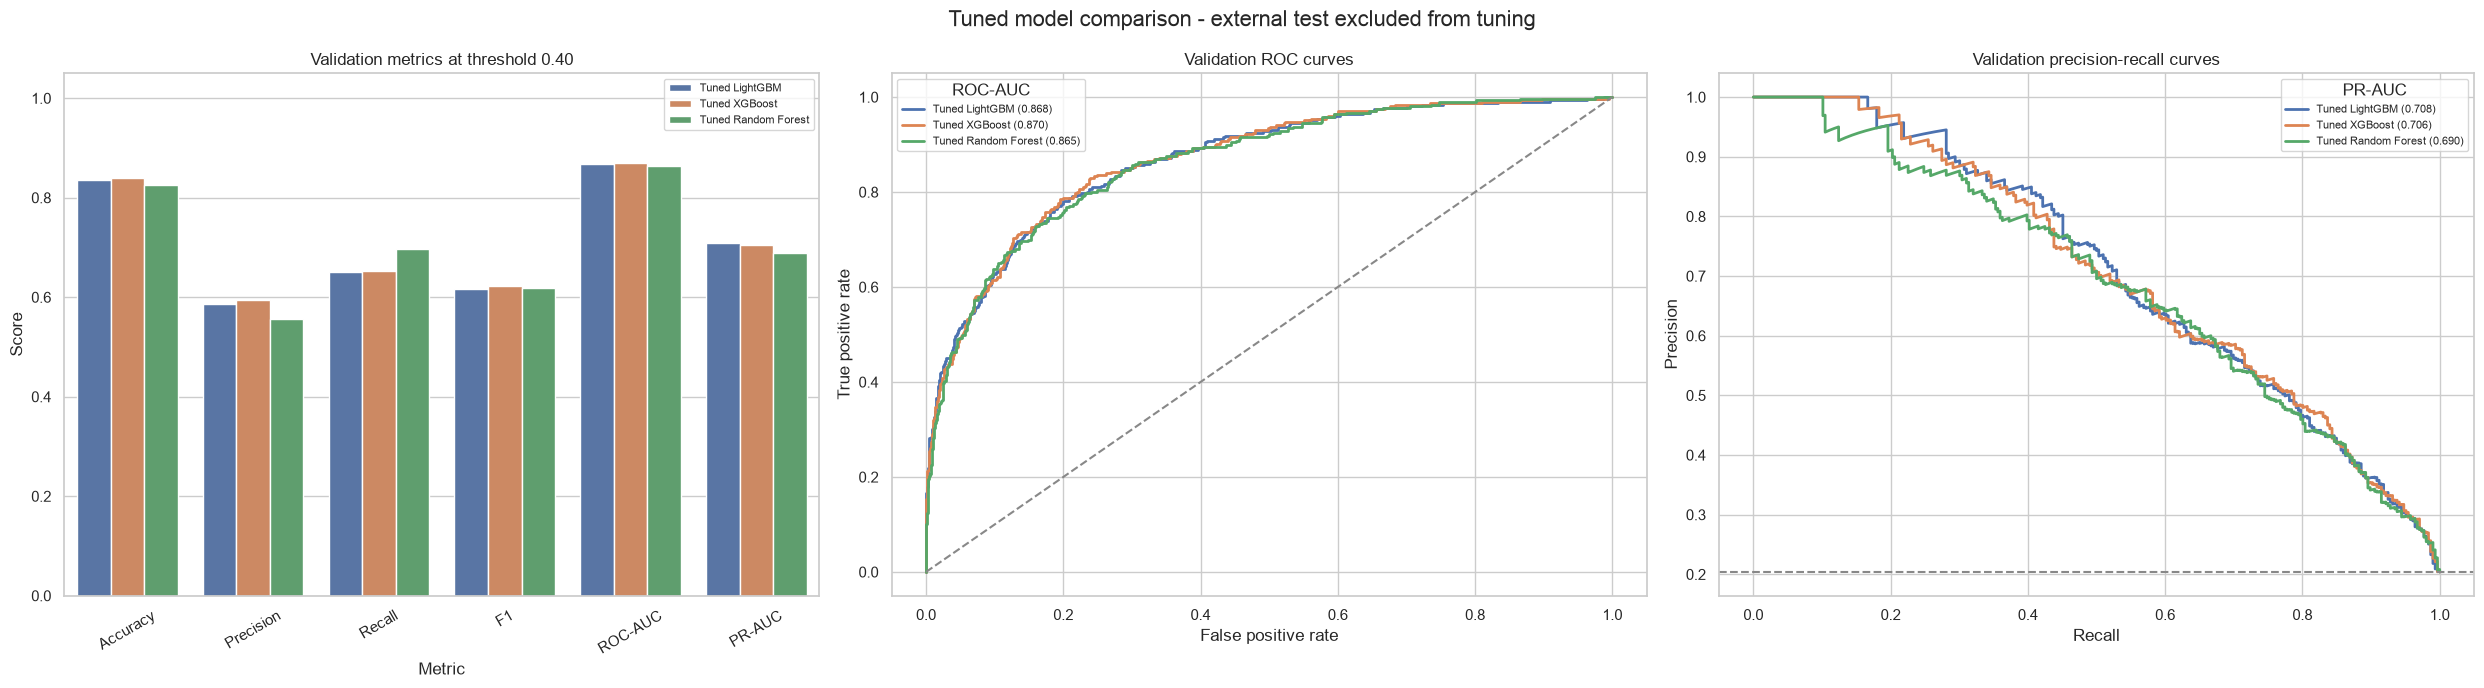

In [10]:
plot_validation_comparison(
    validation_results,
    artifacts,
    data.y_validation,
    config.operating_threshold,
)
plt.show()

# Step 8 — Model selection và threshold report

Các model trong tolerance `0.002` so với CV leader được xem là tương đương; validation F1 tại threshold `0.40` là tie-breaker. External test không tham gia.

In [11]:
selection = select_tuned_model(
    validation_results,
    artifacts,
    data.y_validation,
    config,
)

print(
    f'CV-equivalent shortlist: {selection.shortlist["Model"].tolist()}'
)
print(f'Selected model: {selection.selected_model_name}')
print(
    'Validation-best F0.5 threshold (reference): '
    f'{selection.validation_f05_threshold:.4f}'
)
print(f'Frozen operating threshold: {selection.operating_threshold:.4f}')
display(selection.threshold_comparison.style.format({
    column: '{:.4f}'
    for column in selection.threshold_comparison.columns
    if column != 'Decision rule'
}))

CV-equivalent shortlist: ['Tuned LightGBM', 'Tuned XGBoost']
Selected model: Tuned XGBoost
Validation-best F0.5 threshold (reference): 0.7051
Frozen operating threshold: 0.4000


,Decision rule,Threshold,Accuracy,Precision,Recall,Specificity,F1,F0.5,Balanced Accuracy,ROC-AUC,PR-AUC
0,Default threshold,0.5000,0.8567,0.6717,0.5817,0.9271,0.6235,0.6515,0.7544,0.8699,0.7057
1,Validation-best F0.5 reference,0.7051,0.8613,0.8224,0.4085,0.9774,0.5459,0.6838,0.6929,0.8699,0.7057
2,Business operating threshold,0.4000,0.8387,0.5952,0.6536,0.8861,0.6231,0.6061,0.7698,0.8699,0.7057


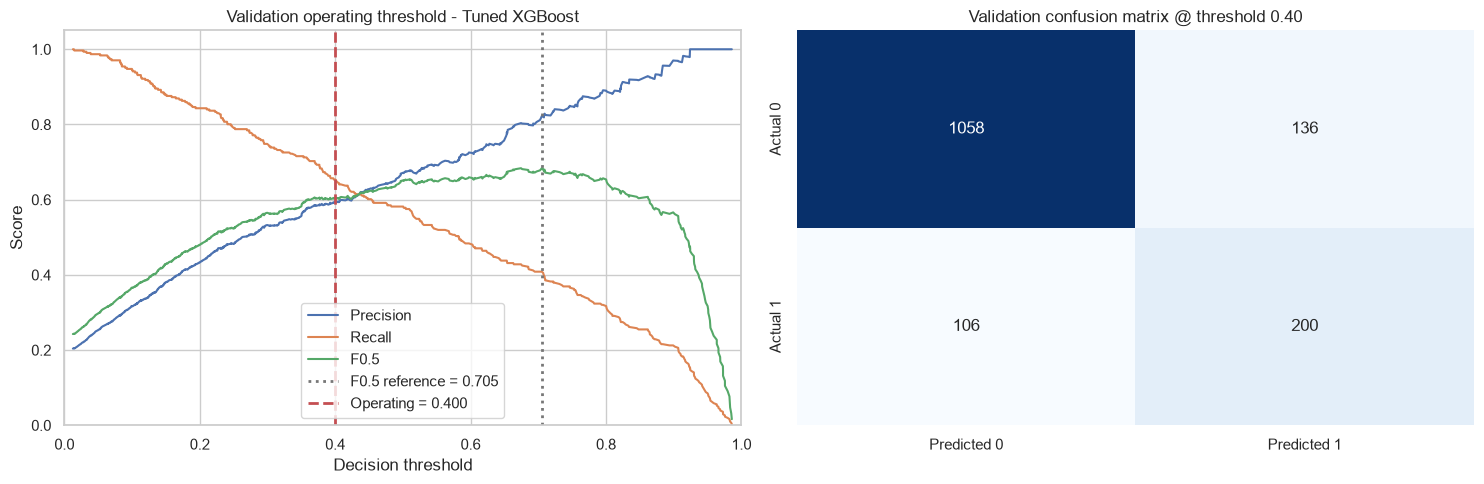

In [12]:
plot_threshold_selection(selection, data.y_validation)
plt.show()

# Step 9 — Final external test evaluation

Từ step này mới dùng `y_test`. Model và threshold đã được đóng băng từ train/validation.

In [13]:
external = evaluate_external_test(selection, data, preprocessing)
display(external.results.style.format({
    'Rows': '{:,}',
    'Actual churn rate': '{:.2%}',
    'Threshold': '{:.4f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'Specificity': '{:.4f}',
    'F1': '{:.4f}',
    'F0.5': '{:.4f}',
    'Balanced Accuracy': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'PR-AUC': '{:.4f}',
}))
print(
    'Confusion matrix [TN FP; FN TP]: '
    f'{external.confusion.tolist()}'
)

,Model,Algorithm,Feature set,Rows,Actual churn rate,Threshold,Accuracy,Precision,Recall,Specificity,F1,F0.5,Balanced Accuracy,ROC-AUC,PR-AUC
0,Tuned XGBoost,XGBoost,engineered,"1,000",20.40%,0.4000,0.8410,0.6098,0.6127,0.8995,0.6112,0.6104,0.7561,0.8691,0.6822


Confusion matrix [TN FP; FN TP]: [[716, 80], [79, 125]]


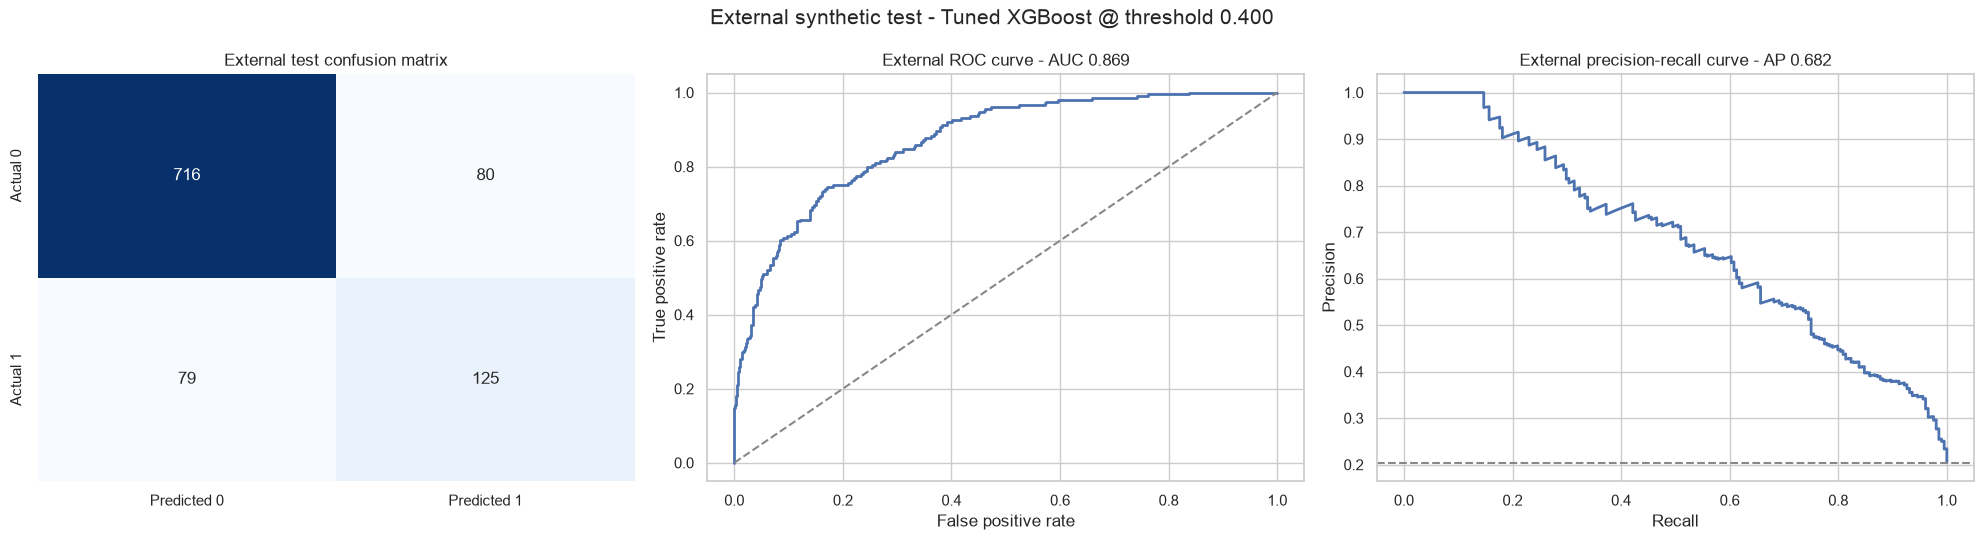

In [14]:
plot_external_evaluation(external, data.y_test, selection)
plt.show()

# Step 10 — Predicted-probability separation

Đường nét đứt là operating threshold; plot so sánh validation và external test theo actual class.

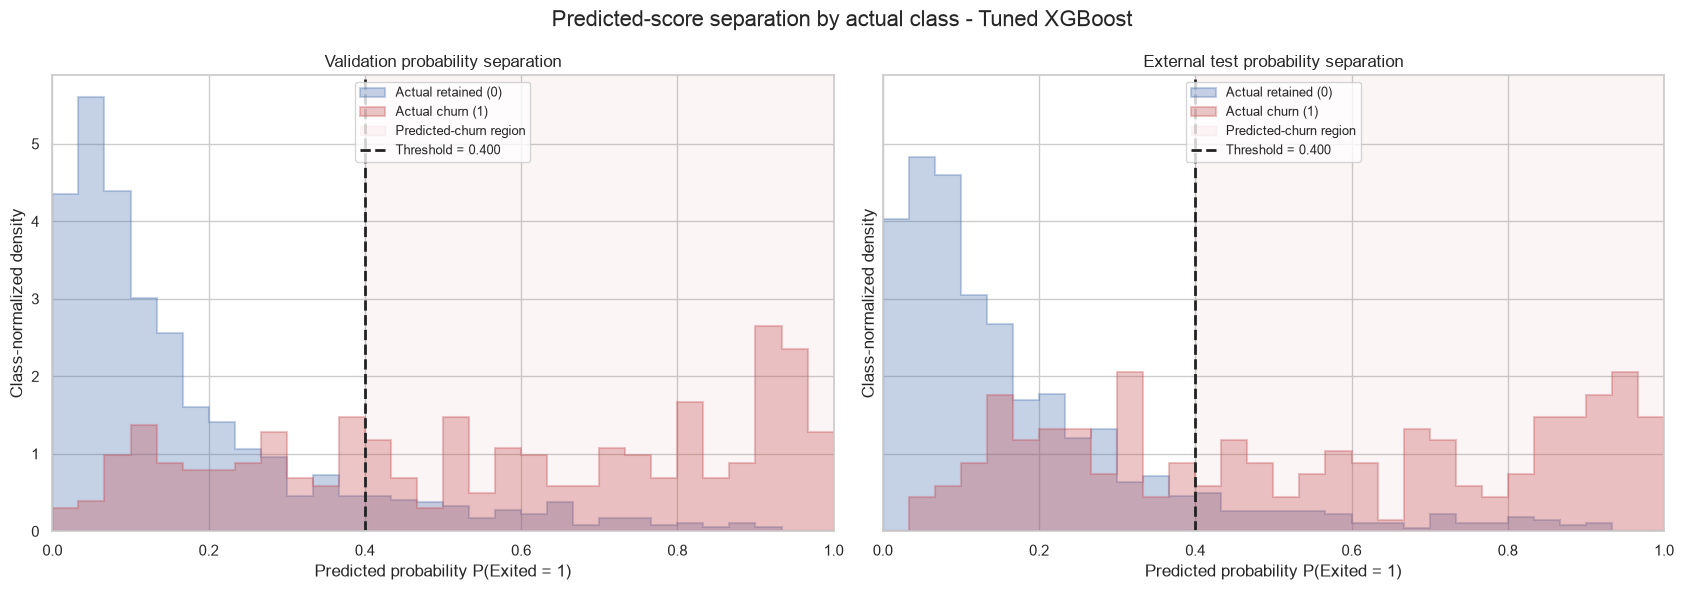

,Split,Actual class,Customers,Mean probability,Median probability,Q25 probability,Q75 probability,Share above threshold
0,Validation,Actual retained (0),"1,194",0.172,0.107,0.049,0.221,11.39%
1,Validation,Actual churn (1),306,0.564,0.582,0.296,0.862,65.36%
2,External test,Actual retained (0),796,0.176,0.115,0.057,0.228,10.05%
3,External test,Actual churn (1),204,0.548,0.547,0.278,0.846,61.27%


In [15]:
_, probability_summary = plot_probability_separation(
    selection,
    data.y_validation,
    external,
    data.y_test,
)
plt.show()
display(probability_summary.style.format({
    'Customers': '{:,}',
    'Mean probability': '{:.3f}',
    'Median probability': '{:.3f}',
    'Q25 probability': '{:.3f}',
    'Q75 probability': '{:.3f}',
    'Share above threshold': '{:.2%}',
}))

# Step 11 — Feature importance

Logic: `pipeline/importance.py`. One-hot importance được cộng về source/engineered feature để so sánh dễ đọc.

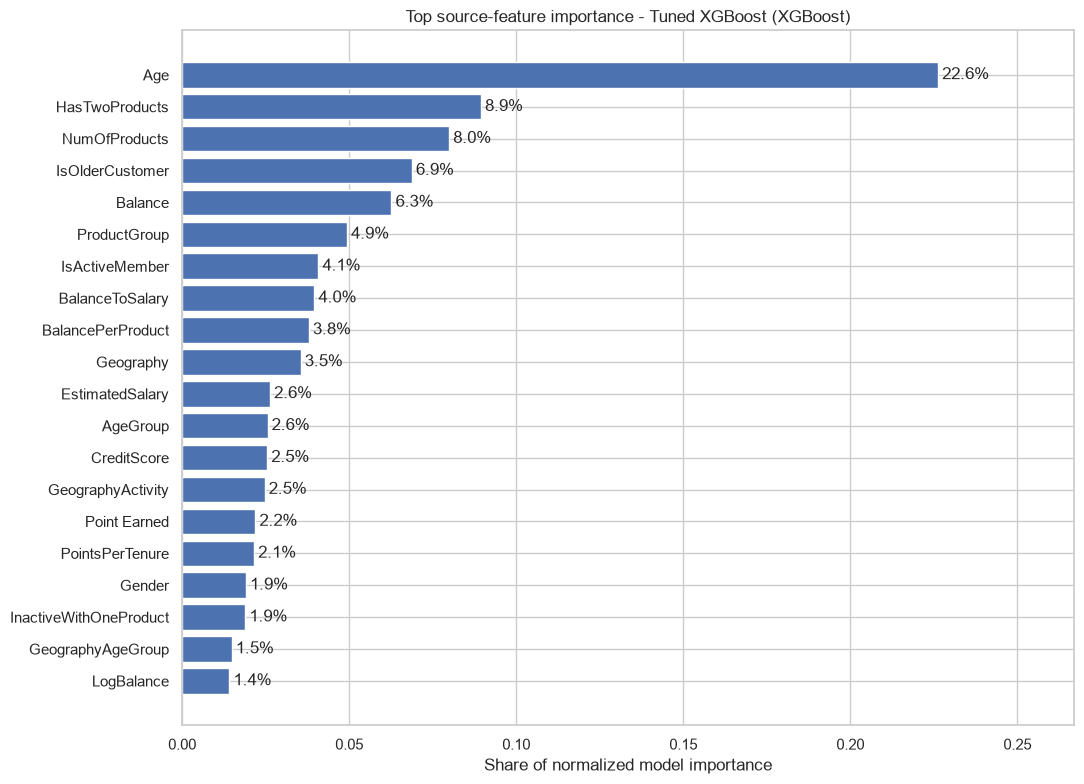

,Source feature,Importance,Importance share
0,Age,"34,653.0",22.62%
1,HasTwoProducts,"13,693.8",8.94%
2,NumOfProducts,"12,235.2",7.99%
3,IsOlderCustomer,"10,527.4",6.87%
4,Balance,"9,593.6",6.26%
5,ProductGroup,"7,555.2",4.93%
6,IsActiveMember,"6,242.6",4.08%
7,BalanceToSalary,"6,059.4",3.96%
8,BalancePerProduct,"5,803.8",3.79%
9,Geography,"5,430.4",3.54%


### Importance riêng của các rule features

,Source feature,Importance,Importance share
0,InactiveWithOneProduct,"2,891.0",1.89%
1,IsInactiveMember,"1,346.2",0.88%
2,LowCreditScore425,203.3,0.13%
3,VeryLowCreditScore,194.3,0.13%
4,InactiveWithThreePlusProducts,69.8,0.05%
5,ShortTenureUnder5,49.8,0.03%
6,VeryLowCreditInactive,0.0,0.00%
7,LowCreditShortTenureHasCard,0.0,0.00%


In [16]:
importance = calculate_source_importance(
    selection.artifact,
    features,
    preprocessing,
)
plot_feature_importance(importance, selection)
plt.show()

display(importance.source.head(20).style.format({
    'Importance': '{:,.1f}',
    'Importance share': '{:.2%}',
}))
display(Markdown('### Importance riêng của các rule features'))
display(importance.rule_features.style.format({
    'Importance': '{:,.1f}',
    'Importance share': '{:.2%}',
}))

# Step 12 — Final comparison và kết luận

Narrative và final table được tạo bởi `pipeline/reporting.py` để notebook không chứa business logic.

In [17]:
final_comparison = build_final_comparison(selection)
display(Markdown(build_conclusion_markdown(
    config,
    data,
    validation_results,
    selection,
    external,
    importance,
)))
display(final_comparison.style.format({
    'CV PR-AUC mean': '{:.4f}',
    'CV PR-AUC std': '{:.4f}',
    'Search seconds': '{:.2f}',
    'Best iteration': '{:,}',
    'Threshold': '{:.2f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
    'Balanced Accuracy': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'PR-AUC': '{:.4f}',
}).background_gradient(
    subset=['PR-AUC', 'ROC-AUC'],
    cmap='YlGn',
))

selected_parameters = pd.DataFrame([
    {'Parameter': key, 'Value': str(value)}
    for key, value in selection.artifact.best_parameters.items()
])
display(Markdown(f'### Best parameters — {selection.selected_model_name}'))
display(selected_parameters.style.hide(axis='index'))
display(Markdown('''
Lưu ý: external test đã được xem ở các vòng thử nghiệm trước nên không còn là blind test hoàn toàn độc lập. Trong lần tuning này nó vẫn bị loại khỏi search và model selection; để có ước lượng production cuối cùng nên khóa thêm một test set mới chưa từng được quan sát.
'''))


# 10. Kết luận tuning

- Protocol: **8,500 train / 1,500 validation** từ source data và **1,000 external test**.
- Tuning: **18 random configurations x 5 stratified folds/model**, scoring bằng PR-AUC; feature engineering và preprocessing được fit lại trong từng fold.
- `RowNumber`, `CustomerId`, `Surname`, `Complain` và `Exited` không xuất hiện trong feature matrix.
- CV leader là **Tuned LightGBM** với PR-AUC **0.7009**. **Tuned XGBoost** thấp hơn **0.0006**, nằm trong tolerance **0.002**, nên được chọn nhờ validation F1 tốt nhất trong nhóm tương đương.
- Model được chọn **Tuned XGBoost** có mean CV PR-AUC **0.7004 ± 0.0217**.
- Validation tại threshold **0.40**: Accuracy **0.8387**, Precision **0.5952**, Recall **0.6536**, F1 **0.6231**, PR-AUC **0.7057**.
- So với **Engineered XGBoost** chưa tuning ở cùng threshold: Precision thay đổi **-0.0616**, Recall **+0.0719**, F1 **+0.0061**.
- Threshold F0.5 tham chiếu từ validation: **0.7051**; operating threshold ưu tiên recall được cố định theo quyết định nghiệp vụ: **0.40**.
- External test: Accuracy **0.8410**, Precision **0.6098**, Recall **0.6127**, F1 **0.6112**, ROC-AUC **0.8691**, PR-AUC **0.6822**.
- Top source features: **Age, HasTwoProducts, NumOfProducts, IsOlderCustomer, Balance, ProductGroup, IsActiveMember, BalanceToSalary**.

## Bảng tổng kết 3 tuned models trên validation

Các metric phụ thuộc quyết định dùng threshold **0.40**. Các model cách CV leader không quá **0.002** được xem là tương đương và validation F1 được dùng để tie-break; external test không dùng để chọn model hoặc tham số.


,Selected,Model,Algorithm,Imbalance strategy,CV PR-AUC mean,CV PR-AUC std,Search seconds,Best iteration,Threshold,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC
0,True,Tuned XGBoost,XGBoost,scale_pos_weight=1.5000,0.7004,0.0217,12.07,500,0.40,0.8387,0.5952,0.6536,0.6231,0.7698,0.8699,0.7057
1,False,Tuned LightGBM,LightGBM,scale_pos_weight=1.5000,0.7009,0.0181,12.32,600,0.40,0.8353,0.5870,0.6503,0.6171,0.7665,0.8678,0.7082
2,False,Tuned Random Forest,Random Forest,"class_weight={0: 1, 1: 2}",0.6887,0.0233,318.45,800,0.40,0.8247,0.5561,0.6961,0.6183,0.7768,0.8646,0.6896


### Best parameters — Tuned XGBoost

Parameter,Value
subsample,0.85
scale_pos_weight,1.5
reg_lambda,2.0
reg_alpha,0.0
n_estimators,500
min_child_weight,3
max_depth,5
learning_rate,0.015
gamma,0.3
colsample_bytree,0.7



Lưu ý: external test đã được xem ở các vòng thử nghiệm trước nên không còn là blind test hoàn toàn độc lập. Trong lần tuning này nó vẫn bị loại khỏi search và model selection; để có ước lượng production cuối cùng nên khóa thêm một test set mới chưa từng được quan sát.
